In [26]:
#TASK 1: DATA ACQUISITION

import pandas as pd

df_titanic = pd.read_excel(r"C:\Users\NanaKay\Documents\python\TITANIC_DATASET_1309.xlsx")

print("Dataset Overview:")
print(f"Shape: {df_titanic.shape}")
print(f"Columns: {list(df_titanic.columns)}\n")
print("First few rows:")
display(df_titanic.head())

Dataset Overview:
Shape: (1309, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First few rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
# TASK 2: DATA PREPROCESSING

# Check missing values
print("Missing Values:")
missing_df = pd.DataFrame({
    "Count": df_titanic.isna().sum(),
    "Percentage": (df_titanic.isna().sum() / len(df_titanic) * 100).round(2)
})
display(missing_df[missing_df["Count"] > 0])

# Remove duplicates
duplicates = df_titanic.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates > 0:
    df_titanic = df_titanic.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")

# Fill missing values
print("\nFilling missing values:")
for col in df_titanic.columns:
    if df_titanic[col].isna().any():
        if df_titanic[col].dtype in ['int64', 'float64']:
            fill_value = df_titanic[col].median()
            df_titanic[col] = df_titanic[col].fillna(fill_value)
            print(f"✓ {col} - filled with median")
        else:
            fill_value = df_titanic[col].mode()[0] if len(df_titanic[col].mode()) > 0 else "Unknown"
            df_titanic[col] = df_titanic[col].fillna(fill_value)
            print(f"✓ {col} - filled with mode")

print("\nPreprocessing complete!")
print(f"Dataset shape: {df_titanic.shape}")

Missing Values:


,Count,Percentage



Duplicate rows: 0

Filling missing values:

Preprocessing complete!
Dataset shape: (1309, 12)


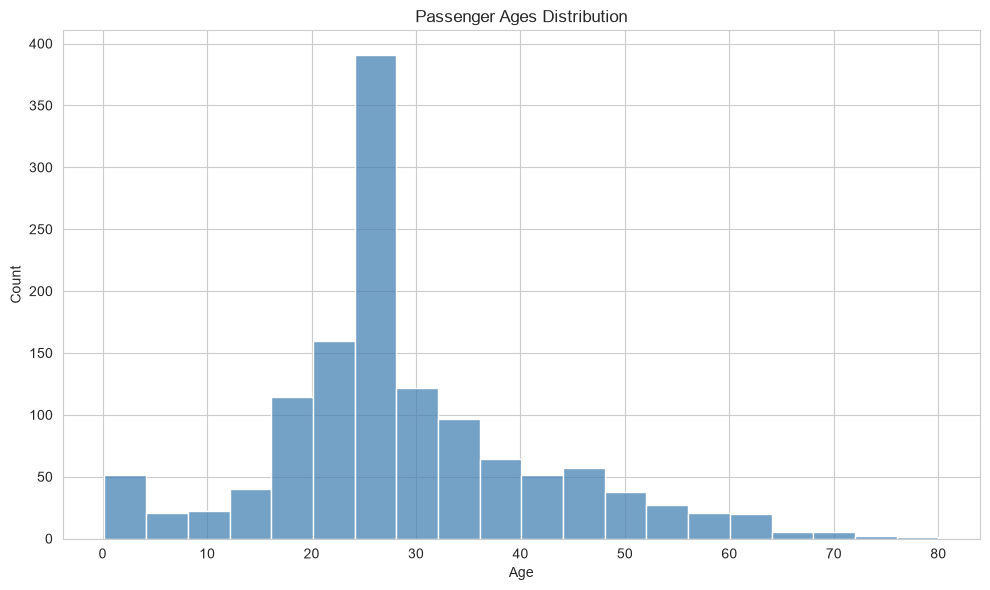

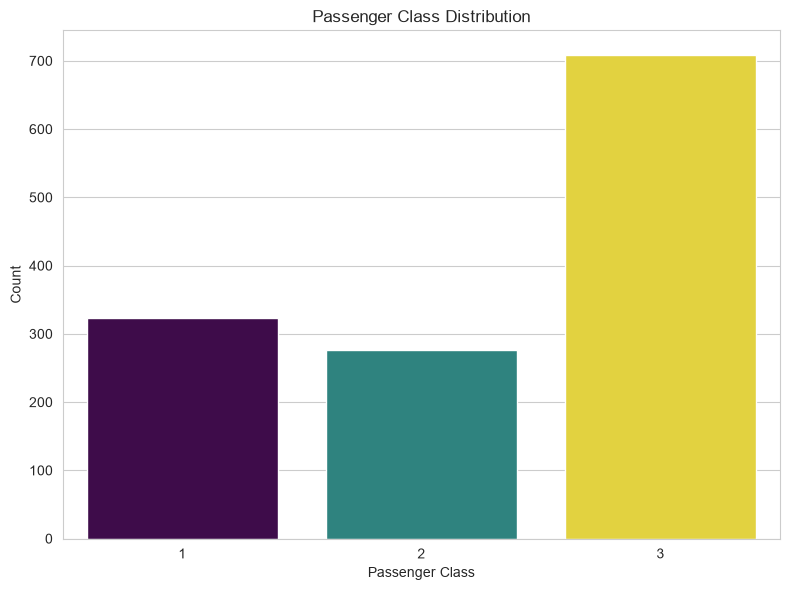

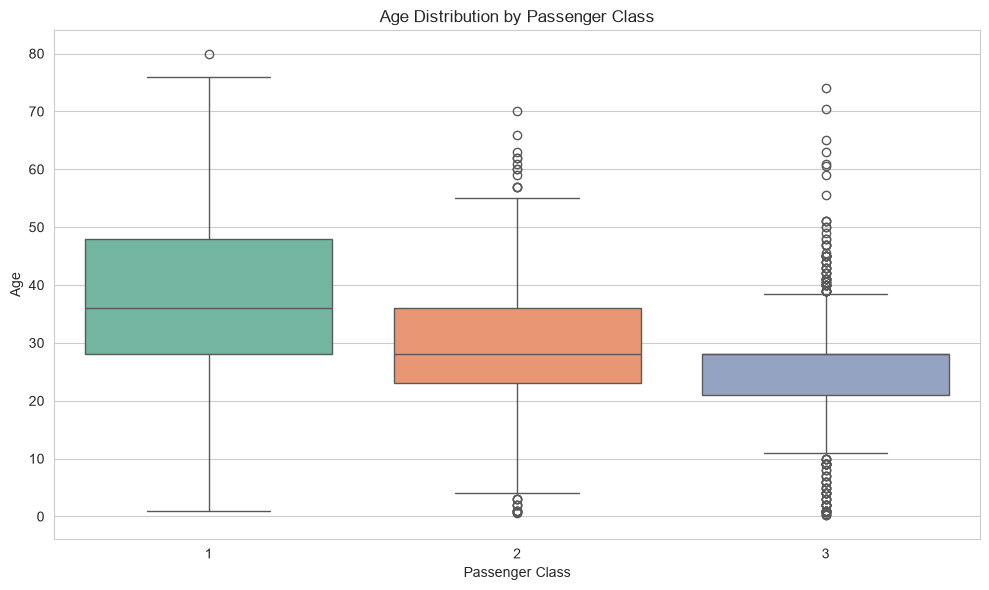

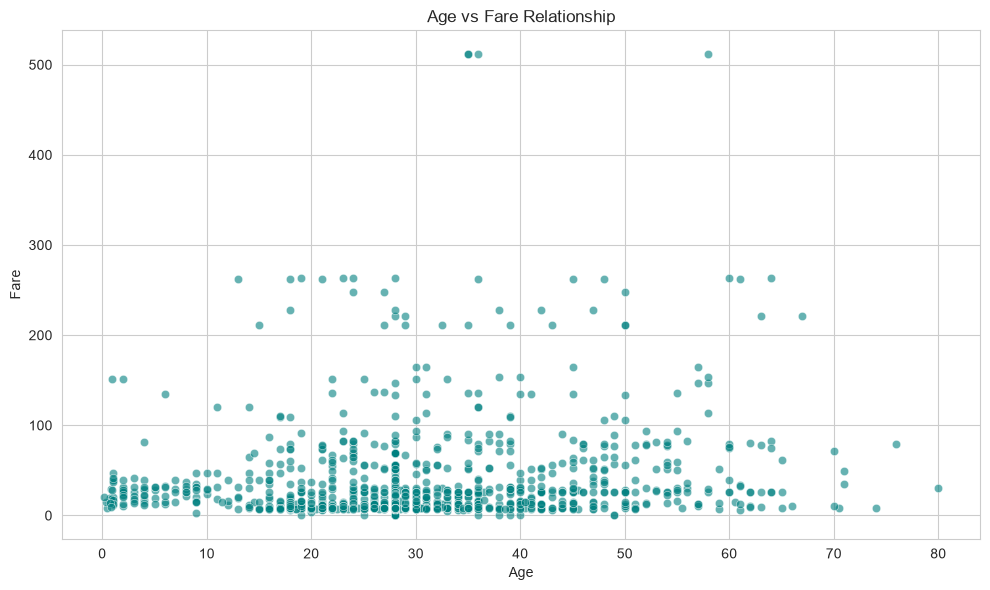

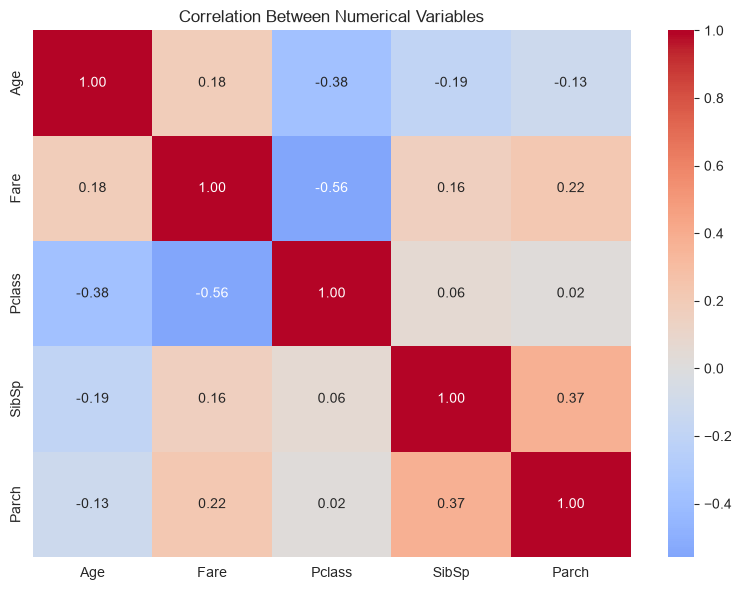

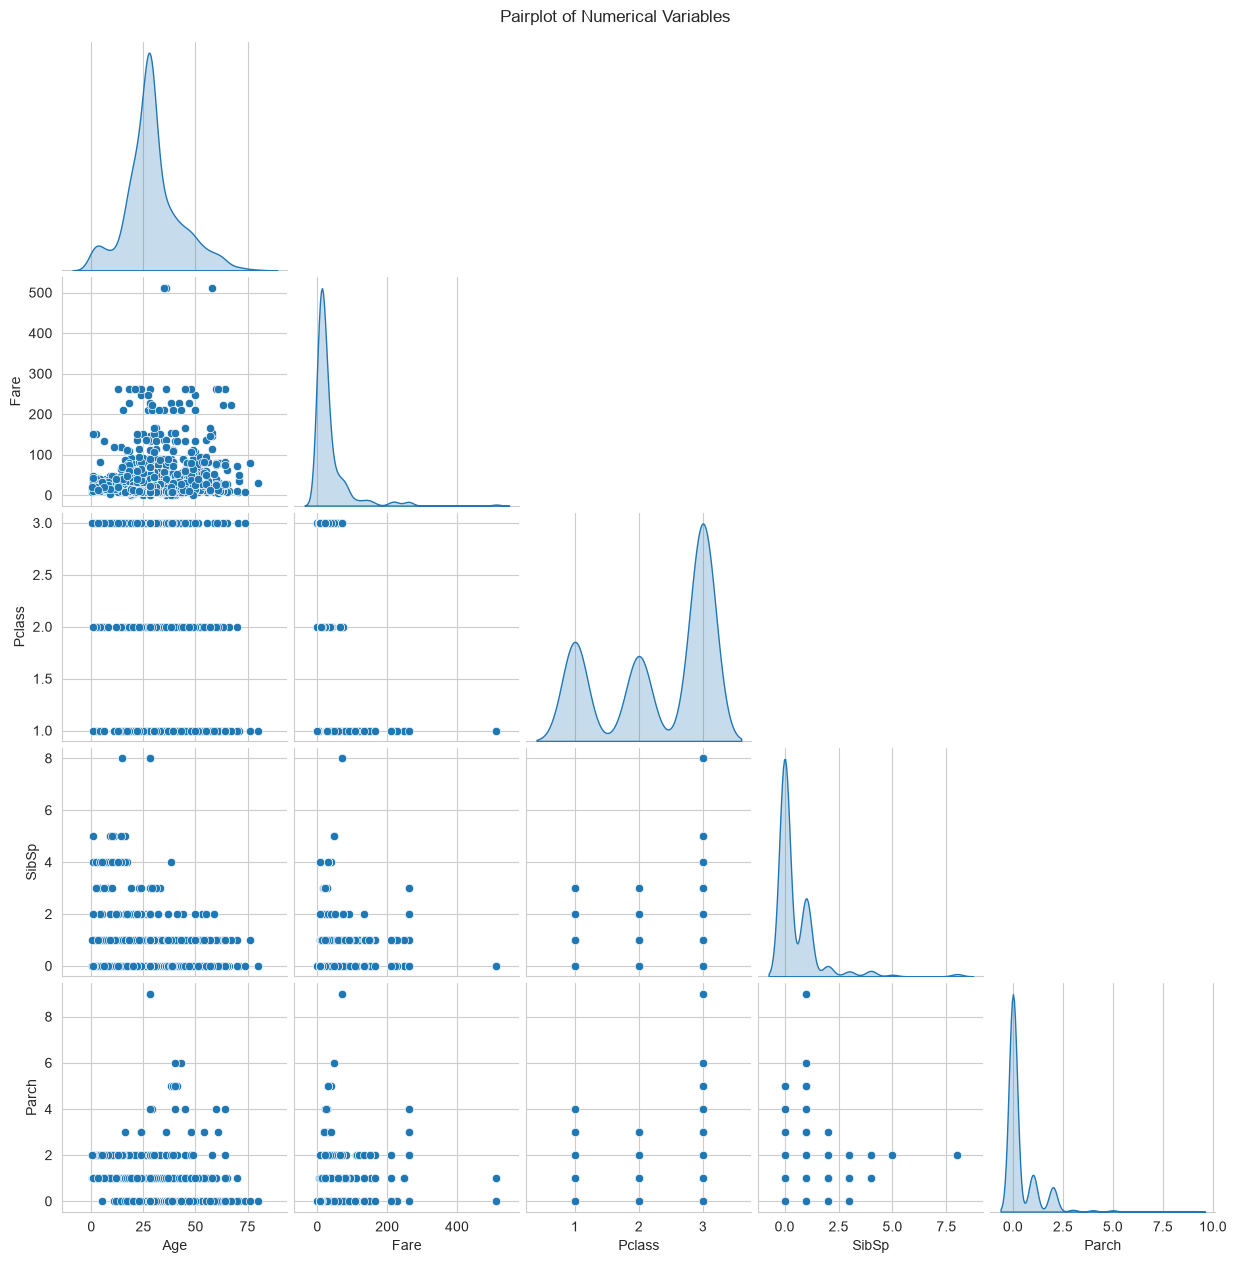

Visualizations complete!


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# TASK 3: VISUALISATION

sns.set_style("whitegrid")

# 1. Histogram of passenger ages
plt.figure(figsize=(10, 6))
sns.histplot(df_titanic["Age"].dropna(), bins=20, kde=False, color="steelblue")
plt.title("Passenger Ages Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2. Passenger class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x="Pclass", hue="Pclass", data=df_titanic, palette="viridis", legend=False)
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3. Age by passenger class
plt.figure(figsize=(10, 6))
sns.boxplot(x="Pclass", y="Age", data=df_titanic, hue="Pclass", palette="Set2", legend=False)
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

# 4. Age vs Fare scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Age", y="Fare", data=df_titanic, alpha=0.6, color="teal")
plt.title("Age vs Fare Relationship")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

# 5. Correlation heatmap
numeric_cols = ["Age", "Fare", "Pclass", "SibSp", "Parch"]
correlation = df_titanic[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.show()

# 6. Pairplot
pairplot_data = df_titanic[numeric_cols].dropna()
sns.pairplot(pairplot_data, diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Numerical Variables", y=1.01)
plt.show()

print("Visualizations complete!")

In [33]:
# TASK 4: STATISTICAL ANALYSIS

import pandas as pd

if 'df_titanic' not in globals():
    df_titanic = pd.read_excel(r"C:\Users\NanaKay\Documents\python\TITANIC_DATASET_1309.xlsx")

# 1) Descriptive statistics for numeric columns
print("1) Numeric Variables - Descriptive Statistics:")
display(df_titanic.describe().transpose())

# 2) Frequency distributions for categorical variables
print("\n2) Categorical Variables - Frequency Distributions:")
cat_vars = ['Pclass', 'Sex', 'Embarked']
for var in cat_vars:
    print(f"\n{var}:")
    counts = df_titanic[var].value_counts(dropna=False)
    percentages = (df_titanic[var].value_counts(normalize=True, dropna=False) * 100).round(2)
    freq_df = pd.DataFrame({'Count': counts, 'Percentage': percentages})
    display(freq_df)

# 3) Correlation analysis
print("\n3) Correlation Matrix:")
numeric = df_titanic.select_dtypes(include=['number'])
corr = numeric.corr()
display(corr)

# 4) Strongest correlations
print("\n4) Key Correlations:")
corr_unstack = corr.unstack()
corr_unstack = corr_unstack[corr_unstack.index.get_level_values(0) != corr_unstack.index.get_level_values(1)]
pairs = {}
for (a, b), val in corr_unstack.items():
    key = tuple(sorted((a, b)))
    if key not in pairs:
        pairs[key] = val
pairs_series = pd.Series(pairs)

if not pairs_series.empty:
    pos_idx = pairs_series.idxmax()
    pos_val = pairs_series.max()
    neg_idx = pairs_series.idxmin()
    neg_val = pairs_series.min()
    print(f"Strongest positive: {pos_idx[0]} & {pos_idx[1]} = {pos_val:.3f}")
    print(f"Strongest negative: {neg_idx[0]} & {neg_idx[1]} = {neg_val:.3f}")

# 5) Key findings
print("\n5) Key Statistical Findings:")
median_age = df_titanic['Age'].median()
mean_age = df_titanic['Age'].mean()
print(f"- Age: Median={median_age:.1f}, Mean={mean_age:.1f}")
print(f"- Most passengers in Class {df_titanic['Pclass'].mode()[0]}")
print(f"- Survival rate: {(df_titanic['Survived'].sum() / len(df_titanic) * 100):.1f}%")

1) Numeric Variables - Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
PassengerId,1309.0,655.000000,378.020061,1.00,328.0000,655.0000,982.000,1309.0000
Survived,1309.0,0.377387,0.484918,0.00,0.0000,0.0000,1.000,1.0000
Pclass,1309.0,2.294882,0.837836,1.00,2.0000,3.0000,3.000,3.0000
Age,1309.0,29.503186,12.905241,0.17,22.0000,28.0000,35.000,80.0000
SibSp,1309.0,0.498854,1.041658,0.00,0.0000,0.0000,1.000,8.0000
Parch,1309.0,0.385027,0.865560,0.00,0.0000,0.0000,0.000,9.0000
Fare,1309.0,33.281086,51.741500,0.00,7.8958,14.4542,31.275,512.3292



2) Categorical Variables - Frequency Distributions:

Pclass:


,Count,Percentage
Pclass,,
3,709,54.16
1,323,24.68
2,277,21.16



Sex:


...


Embarked:


,Count,Percentage
Embarked,,
S,916,69.98
C,270,20.63
Q,123,9.40



3) Correlation Matrix:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.020370,-0.038354,0.025799,-0.055224,0.008942,0.031128
Survived,-0.020370,1.000000,-0.264710,-0.043286,0.002370,0.108919,0.233773
Pclass,-0.038354,-0.264710,1.000000,-0.377908,0.060832,0.018322,-0.558683
Age,0.025799,-0.043286,-0.377908,1.000000,-0.189972,-0.125851,0.178182
SibSp,-0.055224,0.002370,0.060832,-0.189972,1.000000,0.373587,0.160349
Parch,0.008942,0.108919,0.018322,-0.125851,0.373587,1.000000,0.221635
Fare,0.031128,0.233773,-0.558683,0.178182,0.160349,0.221635,1.000000



4) Key Correlations:
Strongest positive: Parch & SibSp = 0.374
Strongest negative: Fare & Pclass = -0.559

5) Key Statistical Findings:
- Age: Median=28.0, Mean=29.5
- Most passengers in Class 3
- Survival rate: 37.7%


In [23]:
# TRAIN TEST SPLIT FOR TASK 5

# Ensure pandas and dataframe are available
if 'pd' not in globals():
    import pandas as pd
if 'df_titanic' not in globals():
    df_titanic = pd.read_excel(r"C:\Users\NanaKay\Documents\python\TITANIC_DATASET_1309.xlsx")

print("="*70)
print("TRAIN TEST SPLIT - TASK 5")
print("="*70)

# 1) Select suitable predictor variables
print("\n1. SELECT PREDICTOR VARIABLES")
print("-" * 70)
target_col = 'Survived'
candidate_features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']
features = [c for c in candidate_features if c in df_titanic.columns]
if target_col not in df_titanic.columns:
    raise ValueError('Target column "Survived" not found in the dataset.')

print(f"Target variable: {target_col}")
print(f"Predictor variables selected: {features}")
print(f"Number of features: {len(features)}")

X = df_titanic[features].copy()
y = df_titanic[target_col].copy()
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# 2) Train/test split
print("\n2. SPLIT INTO TRAIN/TEST")
print("-" * 70)
from sklearn.model_selection import train_test_split
# stratify if possible
stratify_arg = y if y.nunique() > 1 else None
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=stratify_arg)
print(f"Train set size: {X_train.shape[0]} samples (70%)")
print(f"Test set size: {X_test.shape[0]} samples (30%)")
print(f"\nTraining target distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTesting target distribution:")
print(y_test.value_counts().sort_index())
print("\n" + "="*70)

TRAIN TEST SPLIT - TASK 5

1. SELECT PREDICTOR VARIABLES
----------------------------------------------------------------------
Target variable: Survived
Predictor variables selected: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Number of features: 7
Feature matrix shape: (1309, 7)
Target vector shape: (1309,)

2. SPLIT INTO TRAIN/TEST
----------------------------------------------------------------------
Train set size: 916 samples (70%)
Test set size: 393 samples (30%)

Training target distribution:
Survived
0    570
1    346
Name: count, dtype: int64

Testing target distribution:
Survived
0    245
1    148
Name: count, dtype: int64




Confusion Matrix:


,Pred_0 (Did not survive),Pred_1 (Survived)
Actual_0 (Did not survive),227,18
Actual_1 (Survived),38,110


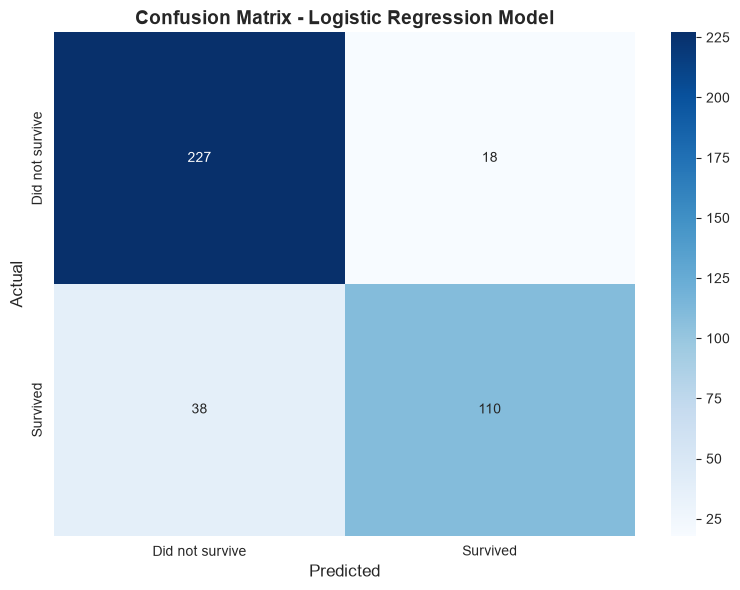


Accuracy: 0.8575 (85.75%)

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       245
           1       0.86      0.74      0.80       148

    accuracy                           0.86       393
   macro avg       0.86      0.83      0.84       393
weighted avg       0.86      0.86      0.86       393


6. BRIEF PERFORMANCE DISCUSSION
----------------------------------------------------------------------
- Model Accuracy: The model achieves 85.75% accuracy on the test set, correctly classifying approximately 86 out of 100 test cases.
- Sensitivity (True Positive Rate): 74.32% - The model correctly identifies 74% of survivors.
- Specificity (True Negative Rate): 92.65% - The model correctly identifies 93% of non-survivors.
- False Positives: 18 - Non-survivors incorrectly predicted as survivors.
- False Negatives: 38 - Survivors incorrectly predicted as non-survivors.
- Interpretation: The model is effective at id

In [21]:
print("\nConfusion Matrix:")
import pandas as _pd
cm_df = _pd.DataFrame(cm, index=['Actual_0 (Did not survive)','Actual_1 (Survived)'], columns=['Pred_0 (Did not survive)','Pred_1 (Survived)'])
display(cm_df)

# Visualize confusion matrix as heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Did not survive', 'Survived'],
            yticklabels=['Did not survive', 'Survived'])
plt.title('Confusion Matrix - Logistic Regression Model', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nAccuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\nClassification Report:")
print(cr)

# 6) Discuss model performance (concise)
print("\n6. BRIEF PERFORMANCE DISCUSSION")
print("-" * 70)
print(f"- Model Accuracy: The model achieves {acc:.2%} accuracy on the test set, correctly classifying approximately {acc*100:.0f} out of 100 test cases.")
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"- Sensitivity (True Positive Rate): {sensitivity:.2%} - The model correctly identifies {sensitivity*100:.0f}% of survivors.")
print(f"- Specificity (True Negative Rate): {specificity:.2%} - The model correctly identifies {specificity*100:.0f}% of non-survivors.")
print(f"- False Positives: {fp} - Non-survivors incorrectly predicted as survivors.")
print(f"- False Negatives: {fn} - Survivors incorrectly predicted as non-survivors.")
print("- Interpretation: The model is effective at identifying non-survivors (high specificity) but less effective at identifying survivors (lower sensitivity).")
print("- Recommendations: Consider cross-validation for robust validation, regularization tuning for better generalization, or tree-based models to capture non-linear patterns.")
print("="*70)